# WELL LOG ANALYZER


## INDEX

1. [Importing](#1)
2. [--](#2)

<a name="1"></a>
### Importing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import os
from scipy.optimize import minimize
import tkinter as tk
from tkinter import filedialog
from IPython.display import display
import os
from matplotlib.backends.backend_pdf import PdfPages
import lasio

In [3]:
def read_log(file_path, file_name)->pd.DataFrame:
    full_path = os.path.join(file_path, file_name)
    _, ext = os.path.splitext(file_name.lower())
    try:
        if ext == ".csv":
            df = pd.read_csv(full_path)
        elif ext == ".las":
            lf = lasio.read(full_path)
            df = lf.df().reset_index()
        elif ext in ['.xls','.xlsx']:
            df = pd.read_excel(full_path)
        print("Printing description of dataset:\n" + str(df.describe()))
        print("Printing available logs:\n" + str(df.columns))
        df = df.replace([-999, -999.25, -999.5, -999.75], np.nan)
        return df
    except Exception as e:
        print(f"Unsupported File Format!\nError: {e}")
        return None


In [4]:
file_path = r"C:\Users\Soumik Dutta\Documents\Petroleum\13Data Science\Well Log Analyzer\data\raw"
file_name = r"Example.LAS"
df = read_log(file_path, file_name)

Printing description of dataset:
              DEPTH     ABDCQF01     ABDCQF02     ABDCQF03     ABDCQF04  \
count  33191.000000  3226.000000  3226.000000  3226.000000  3226.000000   
mean    1805.400000     2.449846     2.447409     2.447272     2.449575   
std      958.156073     0.131558     0.130183     0.131161     0.132434   
min      145.900000     2.104600     2.118200     2.090200     2.124700   
25%      975.650000     2.366375     2.359250     2.361750     2.360050   
50%     1805.400000     2.479150     2.478850     2.478250     2.479650   
75%     2635.150000     2.527275     2.526050     2.525200     2.526225   
max     3464.900000     3.057700     3.052100     3.050500     3.086600   

                 BS         CALI         DRHO           DT          DTS  ...  \
count  33191.000000  3519.000000  3526.000000  4262.000000  3809.000000  ...   
mean      19.043252     8.677213     0.053590    80.380006   138.251061  ...   
std        6.613720     0.083978     0.023488    14

In [5]:
df.to_csv(r"C:\Users\Soumik Dutta\Documents\Petroleum\13Data Science\Well Log Analyzer\data\processed\Example.csv", index=False)

In [6]:
def cleaning_log(df, valid_logs = None)->pd.DataFrame:
    try:
        try:
            df = df[valid_logs]
        except Exception as e:
            print(f"Error: {e}\nProceeding with all available logs.")
        df = df.dropna(axis = 0)
        print("Printing description of cleaned dataset:\n" + str(df.describe()))
        return df
    except Exception as e:
        print(f"Error: {e}")


In [7]:
df = cleaning_log(df, ['DEPTH','BS', 'CALI', 'GR', 'RM', 'RD', 'RT', 'RHOB', 'NPHI', 'DRHO', 'DT', 'DTS', 'PEF'])

Printing description of cleaned dataset:
             DEPTH      BS         CALI           GR           RM  \
count  2813.000000  2813.0  2813.000000  2813.000000  2813.000000   
mean   3272.211234     8.5     8.667867    51.788297     4.476485   
std      96.909413     0.0     0.038018    27.740720    14.075433   
min    3098.500000     8.5     8.360900     8.001500     0.234900   
25%    3205.200000     8.5     8.663700    36.332600     1.339300   
50%    3284.000000     8.5     8.663700    47.600200     1.670200   
75%    3354.300000     8.5     8.697600    57.254100     2.475700   
max    3424.600000     8.5     8.799100   160.992400   134.704100   

                RD           RT         RHOB         NPHI         DRHO  \
count  2813.000000  2813.000000  2813.000000  2813.000000  2813.000000   
mean      3.527763     4.476485     2.471040     0.174779     0.051649   
std       9.242271    14.075399     0.121311     0.057355     0.012793   
min       0.373400     0.234900     2.150

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def gr_constant_selector(gr_values, constant_selector = None):
    """
    Function to select shale and sand constants based on the provided method.
    Args:
        gr_values (pd.Series): The gamma ray values.
        constant_selector (str): The method to select constants. Options are:
        - None: Use the maximum and minimum values of the gamma ray log.
        - 'averaged': Use the average of the three highest and three lowest values.
        - 'user_defined': Prompt the user to input shale and sand values.
    Returns:
        tuple: A tuple containing the shale and sand constants (gr_shale, gr_sand).
    """
    if constant_selector is None:
        try:
            gr_shale = np.max(gr_values)
            gr_sand = np.min(gr_values)         
        except Exception as e:
            print(f"Error calculating shale value: {e}")
            gr_shale = np.nan
            gr_sand = np.nan
    elif constant_selector == 'averaged':
        try:
            gr_shale = gr_values.nlargest(3).mean()
            gr_sand = gr_values.nsmallest(3).mean()
        except Exception as e:
            print(f"Error calculating averaged values: {e}")
            gr_shale = np.nan
            gr_sand = np.nan
    elif constant_selector == 'user_defined':
        try:
            gr_shale = float(input("Enter the shale value: "))
            gr_sand = float(input("Enter the sand value: "))
        except Exception as e:
            print(f"Error with user-defined values: {e}")
            gr_shale = np.nan
            gr_sand = np.nan
    else:
        print(f"Invalid constant_selector value: {constant_selector}. Using default method.")
        try:
            gr_shale = np.max(gr_values)
            gr_sand = np.min(gr_values)         
        except Exception as e:
            print(f"Error calculating shale value: {e}")
            gr_shale = np.nan
            gr_sand = np.nan

    return gr_shale, gr_sand

def linear_shale_model(gr_values, gr_shale, gr_sand):
    """
    Calulates the volume of shale using the linear shale model. For younger formations, and quick estimations.
    Args:
        gr_values (pd.Series): The gamma ray values.
        gr_shale (float): The gamma ray value for shale.
        gr_sand (float): The gamma ray value for sand.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    try:
        if gr_shale == gr_sand:
            raise ValueError("Shale and sand values are equal, cannot compute GR.")
        gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
        return gr_normalized.clip(0, 1)
    except Exception as e:
        print(f"Error in linear shale model: {e}")
        return None
    
def larionov_shale_model(gr_values, gr_shale, gr_sand, age_rock):
    """
    Calculates the volume of shale using the Larionov shale model. Pre- tertiary accounts for older rocks. Tertiary accounts for non-linear increase in shale radioactivity. 
    Args:
        gr_values (pd.Series): The gamma ray values.
        gr_shale (float): The gamma ray value for shale.
        gr_sand (float): The gamma ray value for sand.
        age_rock (str): The age of the rock, either 'pre-tertiary' or 'tertiary'.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    if age_rock == 'pre-tertiary':
        gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
        V_shale = 0.33 * (2 ** (2 * gr_normalized) - 1)
    elif age_rock == 'tertiary':
        gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
        V_shale = 0.083 * (2 ** (3.7 * gr_normalized) - 1)
    else:
        raise ValueError("Invalid age_rock value. Must be 'pre-tertiary' or 'tertiary'.")
    return V_shale.clip(0, 1)

def steiber_shale_model(gr_values, gr_shale, gr_sand):
    """
    Calculates the volume of shale using the Steiber shale model. Accounts for dispersed shales and laminated sands.
    Args:
        gr_values (pd.Series): The gamma ray values.
        gr_shale (float): The gamma ray value for shale.
        gr_sand (float): The gamma ray value for sand.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
    V_shale = gr_normalized / (3 - 2*gr_normalized)
    return V_shale.clip(0, 1)

def clavier_shale_model(gr_values, gr_shale, gr_sand):
    """
    Calculates the volume of shale using the Clavier shale model. Accounts for highly radioactive shales and complex lithology.
    Args:
        gr_values (pd.Series): The gamma ray values.
        gr_shale (float): The gamma ray value for shale.
        gr_sand (float): The gamma ray value for sand.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
    V_shale = 1.7 - (3.38 - (gr_normalized + 0.7)**2)**0.5
    return V_shale.clip(0, 1)

def dresser_atlas_shale_model(gr_values, gr_shale, gr_sand):
    """
    Calculates the volume of shale using the Dresser Atlas shale model. General purpose and smooth transition.
    Args:
        gr_values (pd.Series): The gamma ray values.
        gr_shale (float): The gamma ray value for shale.
        gr_sand (float): The gamma ray value for sand.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    gr_normalized = (gr_values - gr_sand) / (gr_shale - gr_sand)
    V_shale = gr_normalized / (0.6 + 0.4*gr_normalized)
    return V_shale.clip(0, 1)

def calculate_shale_volume(df, gr_col = 'GR', depth_col = 'DEPTH', constant_selector = None, shale_model = None):
    """
    Calculates the volume of shale using the specified shale model and constants.
    Args:
        df (pd.DataFrame): The DataFrame containing the gamma ray and depth logs.
        gr_col (str): The name of the gamma ray column in the DataFrame.
        depth_col (str): The name of the depth column in the DataFrame.
        constant_selector (str): The method to select constants. Options are:
            - None: Use the maximum and minimum values of the gamma ray log.
            - 'averaged': Use the average of the three highest and three lowest values.
            - 'user_defined': Prompt the user to input shale and sand values.
        shale_model (str): The shale model to use. Options are:
            - 'linear': Use the linear shale model.
            - 'larionov': Use the Larionov shale model.
            - 'steiber': Use the Steiber shale model.
            - 'clavier': Use the Clavier shale model.
            - 'dresser_atlas': Use the Dresser Atlas shale model.
    Returns:
        pd.Series: The calculated volume of shale.
    """
    try:
        if gr_col not in df.columns or depth_col not in df.columns:
            raise ValueError(f"Columns '{gr_col}' and/or '{depth_col}' not found in DataFrame.")
        gr_values = df[gr_col]
    except Exception as e:
        print(f"Error: {e}")
        return None
    gr_shale, gr_sand = gr_constant_selector(gr_values, constant_selector)
    if shale_model == 'linear':
        return linear_shale_model(gr_values, gr_shale, gr_sand)
    elif shale_model == 'larionov':
        age_rock = input("Enter the age of the rock ('pre-tertiary' or 'tertiary'): ")
        return larionov_shale_model(gr_values, gr_shale, gr_sand, age_rock)
    elif shale_model == 'steiber':
        return steiber_shale_model(gr_values, gr_shale, gr_sand)
    elif shale_model == 'clavier':
        return clavier_shale_model(gr_values, gr_shale, gr_sand)
    elif shale_model == 'dresser_atlas':
        return dresser_atlas_shale_model(gr_values, gr_shale, gr_sand)
    else:
        return linear_shale_model(gr_values, gr_shale, gr_sand)




In [32]:
Vsh = calculate_shale_volume(df, gr_col = 'GR', depth_col = 'DEPTH', constant_selector = 'averaged', shale_model = 'linear')

In [33]:
Vsh

29526    0.141945
29527    0.135178
29528    0.124568
29529    0.114323
29530    0.108028
           ...   
32783    0.286099
32784    0.294525
32785    0.301296
32786    0.292721
32787    0.286114
Name: GR, Length: 2813, dtype: float64

In [34]:
df['Vsh_linear'] = Vsh

In [35]:
df['Vsh_linear'].describe()

count    2813.000000
mean        0.286786
std         0.181876
min         0.000000
25%         0.185451
50%         0.259328
75%         0.322624
max         1.000000
Name: Vsh_linear, dtype: float64

In [ ]:
def calculate_non_shale_logs(df, gr_col = 'GR', depth_col = 'DEPTH', vsh_col = 'Vsh', logs_convert = None, shale_properties = None):
    """
    Converts the logs to non-shale values using the calculated shale volume. This is done by finding the shale point where Vsh is 1.0 and using that to calculate the non-shale values for the specified logs.
    Args:        
        df (pd.DataFrame): The DataFrame containing the logs.
        gr_col (str): The name of the gamma ray column in the DataFrame.
        depth_col (str): The name of the depth column in the DataFrame.
        vsh_col (str): The name of the shale volume column in the DataFrame.
        logs_convert (list): A list of log names to convert to non-shale values.
        shale_properties (dict): A dictionary containing the shale properties for each log.
    Returns:
        pd.DataFrame: The DataFrame with the non-shale logs added.
        dict: A dictionary containing the shale properties for each log.    
    """
    shale_point = df.iloc[np.where(df[vsh_col] == 1.0)[0]] if shale_properties is None else pd.DataFrame(shale_properties, index=[0])
    if shale_point.empty:
        print("No shale point found where Vsh is exactly 1.0.")
        shale_point = df.iloc[df[vsh_col].argmax()]
    print(f"Shale point:\n{shale_point}")
    shale_properties = {}
    for log in logs_convert:
        shale_property = np.mean(shale_point[log].values)
        shale_properties[log] = shale_property
        print(f"Shale property for {log}: {shale_property}")
        df[f"{log}_ns"] = (df[log] - shale_property*df[vsh_col]) / (1 - df[vsh_col])
        df[f"{log}_ns"] = df[f"{log}_ns"].replace([np.inf, -np.inf], 0.)
    return df, shale_properties

In [69]:
df, shale_properties = calculate_non_shale_logs(df, gr_col = 'GR', depth_col = 'DEPTH', vsh_col = 'Vsh_linear', logs_convert = ['RHOB', 'NPHI', 'PEF'])

Shale point:
        DEPTH   BS    CALI        GR      RM      RD      RT    RHOB    NPHI  \
30667  3212.6  8.5  8.6975  160.8678  1.4463  1.5147  1.4464  2.4209  0.3502   
30668  3212.7  8.5  8.6805  160.9924  1.5512  1.5679  1.5512  2.4175  0.3471   

         DRHO        DT       DTS     PEF  Vsh_linear  RHOB_ns  NPHI_ns  \
30667  0.0336  104.6843  201.9309  5.8322         1.0      0.0      0.0   
30668  0.0293  104.1314  201.9939  5.8383         1.0      0.0      0.0   

       PEF_ns  
30667     0.0  
30668     0.0  
Shale property for RHOB: 2.4192
Shale property for NPHI: 0.34865
Shale property for PEF: 5.83525


In [70]:
df

,DEPTH,BS,CALI,GR,RM,RD,RT,RHOB,NPHI,DRHO,DT,DTS,PEF,Vsh_linear,RHOB_ns,NPHI_ns,PEF_ns
29526,3098.5,8.5,8.6637,29.6970,2.7973,2.9917,2.7973,2.5399,0.0961,0.0512,66.5415,143.1381,7.7100,0.141945,2.559867,0.054322,8.020132
29527,3098.6,8.5,8.6637,28.6650,2.8771,3.0600,2.8773,2.5789,0.0932,0.0589,66.6841,141.9173,7.5277,0.135178,2.603862,0.053271,7.792243
29528,3098.7,8.5,8.6637,27.0468,3.0938,3.2173,3.0939,2.5917,0.0893,0.0558,66.9923,141.3747,7.5301,0.124568,2.616246,0.052396,7.771267
29529,3098.8,8.5,8.6637,25.4841,3.1813,3.3115,3.1815,2.5920,0.0846,0.0480,67.2518,141.1851,7.5670,0.114323,2.614305,0.050517,7.790533
29530,3098.9,8.5,8.6637,24.5240,3.3397,3.4340,3.3400,2.5909,0.0799,0.0419,67.4621,141.3413,7.6240,0.108028,2.611695,0.047351,7.840637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32783,3424.2,8.5,8.7231,51.6833,1.1323,1.1774,1.1323,2.4461,0.1875,0.0557,76.4480,136.8919,6.2810,0.286099,2.456880,0.122919,6.459636
32784,3424.3,8.5,8.7483,52.9685,1.1693,1.1964,1.1693,2.4506,0.1850,0.0579,76.1982,136.7067,6.3838,0.294525,2.463709,0.116679,6.612811
32785,3424.4,8.5,8.7485,54.0012,1.1792,1.2145,1.1792,2.4563,0.1785,0.0603,75.8560,136.5749,6.4731,0.301296,2.472298,0.105128,6.748155
32786,3424.5,8.5,8.7735,52.6933,1.2080,1.2347,1.2081,2.4590,0.1777,0.0603,75.5494,135.3308,6.5220,0.292721,2.475472,0.106949,6.806224


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def density_neutron_crossplot(df, rhob_col = 'RHOB', nphi_col = 'NPHI', rhob_col_ns = 'RHOB_ns', nphi_col_ns = 'NPHI_ns'):
    """
    Creates a density-neutron crossplot using the specified columns for bulk density and neutron porosity.
    Args:
        df (pd.DataFrame): The DataFrame containing the bulk density and neutron porosity logs.
        rhob_col (str): The name of the bulk density column in the DataFrame.
        nphi_col (str): The name of the neutron porosity column in the DataFrame.
        rhob_col_ns (str): The name of the non-shale bulk density column in the DataFrame.
        nphi_col_ns (str): The name of the non-shale neutron porosity column in the DataFrame.
    """
    try:
        if rhob_col_ns not in df.columns or nphi_col_ns not in df.columns:
            raise ValueError(f"Columns '{rhob_col_ns}' and/or '{nphi_col_ns}' not found in DataFrame.")
        rhob_ns = df[rhob_col_ns]
        nphi_ns = df[nphi_col_ns]
        if rhob_col not in df.columns or nphi_col not in df.columns:
            print(f"Warning: Columns '{rhob_col}' and/or '{nphi_col}' not found in DataFrame. Using non-shale logs for crossplot.")
        rhob_raw = df[rhob_col]
        nphi_raw = df[nphi_col]
    except Exception as e:
        print(f"Error: {e}")
        return None
    phi = np.linspace(0, 0.45, 200)
    rho_f = 1.0

    lithologies = {
    "Sandstone": {"rho_ma": 2.65, "phiN_ma": -0.02},
    "Limestone": {"rho_ma": 2.71, "phiN_ma": 0.00},
    "Dolomite":  {"rho_ma": 2.87, "phiN_ma": 0.02}
    }
    phi_labels = np.arange(0.0, 0.5, 0.1)

    fig, axes = plt.subplots(1, 2, figsize=(14,7), sharey=True)
    for ax, nphi, rhob, title in zip(
    axes,
    [nphi_raw, nphi_ns],
    [rhob_raw, rhob_ns],
    ["Raw Logs", "Shale Corrected Logs"]):
        ax.scatter(nphi, rhob, s=6, alpha=0.6)

        for name, props in lithologies.items():
            rho_line = phi * rho_f + (1 - phi) * props["rho_ma"]
            phiN_line = (1 - phi) * props["phiN_ma"] + phi * 1.0
            ax.plot(phiN_line, rho_line, linewidth=2, label=name)

            for p in phi_labels:
                rho_p = p * rho_f + (1 - p) * props["rho_ma"]
                phiN_p = (1 - p) * props["phiN_ma"] + p * 1.0
                ax.plot(phiN_p, rho_p, 'o', markersize=3)

        ax.set_xlim(-0.05, 0.45)
        ax.set_ylim(3.0, 1.9)

        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))
        ax.yaxis.set_major_locator(MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(MultipleLocator(0.02))

        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6)
        ax.grid(which='minor', linestyle='-', linewidth=0.3, alpha=0.3)

        ax.set_title(title)
        ax.set_xlabel("NPHI (fraction)")

    axes[0].set_ylabel("RHOB (g/cc)")

    axes[0].legend()

plt.suptitle("Neutron–Density Crossplot: Effect of Shale Correction")
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

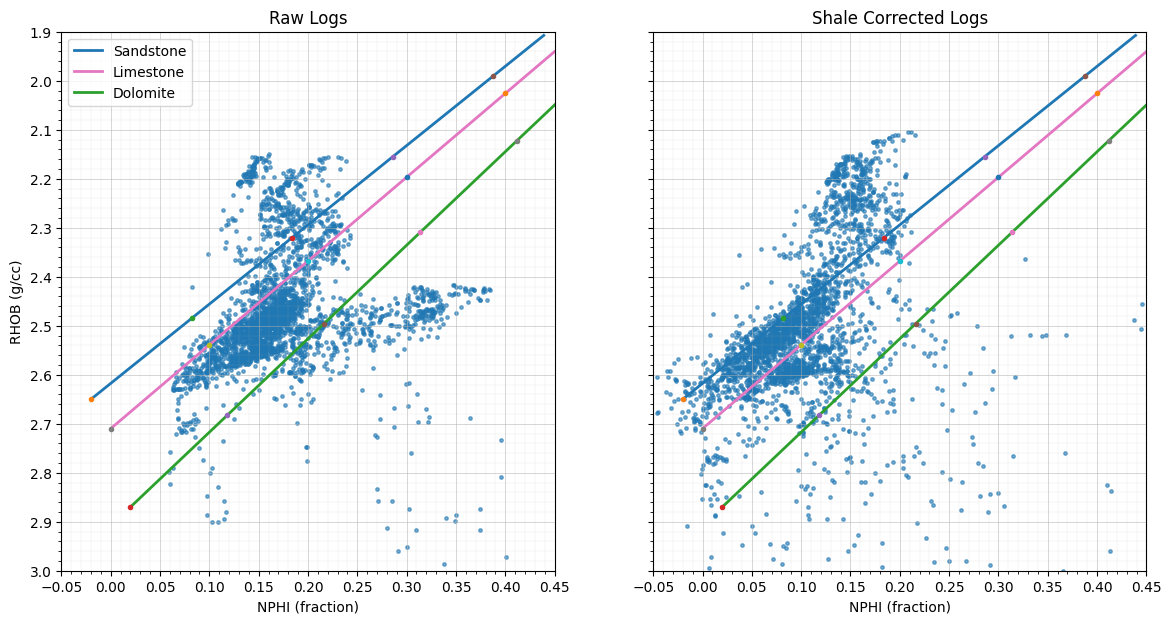

In [73]:
density_neutron_crossplot(df, rhob_col = 'RHOB', nphi_col = 'NPHI', rhob_col_ns = 'RHOB_ns', nphi_col_ns = 'NPHI_ns')